# MOD510: Project 2

**Deadline: 13. October 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract
Write abstract here

# Introduction
Write intro here

# Exercise 1: Steady-state solution

In this exercise we study the steady-state solution. At steady state there is no pressure variation in time. This is the first step towards building the full time-dependent reservoir simulator that we created in the later exercises. Here we derive the analytical solution, before we later find the numerical solution by discretizing using finite differences. Finally, we explore different boundary conditions and explore how numerical errors change by comparing them to the analytical solution.

## Part 1

We start off with solving equation $(16)$:

$$\frac{d^2p}{dy^2}(y) = y \quad \text{for all $x$} \quad \Rightarrow \quad \frac{d^2p}{dy^2} = 0$$

To solve equation $(16)$ we start by with integrating on both sides with respect to $y$:

$$\int \frac{d^2p}{dy^2} \text{ dy} = \int 0 \text{ dy} \quad \Rightarrow \quad \frac{dp}{dy} = C_1$$

Equation $(17)$ tells us that: 

$$\frac{dp}{dy} = \alpha$$

Therefore we can conclude that: 

$$C_1 = \alpha$$

With $C_1 = \alpha$ we can integrate once more to solve for $p(y)$:

$$\frac{dp}{dy} = C_1 \quad \Rightarrow \quad \frac{dp}{dy} = \alpha \quad \Rightarrow \quad \int \text{ d}p = \int \alpha \text{ dy} \quad \Rightarrow \quad p(y) = \alpha \cdot y + C_2$$

In order to solve for $C_2$ we can use equation $(18)$ that says $p(y_e) = p_{init}$ :

$$p(y = y_e) = \alpha \cdot y_e + C_2 = p_{init} \quad \Rightarrow \quad C_2 = p_{init} - \alpha \cdot y_e$$

Now we can insert our solution for $c_2$ into our equation for $p(y)$, and with some simple algebra we end up with equation $(19)$ :  

$$p(y) = \alpha \cdot y + C_2 \quad \Rightarrow \quad p(y) = \alpha \cdot y + p_{init} - \alpha \cdot y_e \quad \Rightarrow \quad p(y) = \alpha \cdot y - \alpha \cdot y_e + p_{init}  \quad \Rightarrow \quad p(y) = \alpha ( y - y_e) + p_{init}$$

## Part 2

Here we need to find the finite difference discretization. To do this we have to replace $\frac{d^2p}{dy^2}$ with a suitable finite difference formula. Finally, we changed the notation to simplify calculations. 

$$\frac{d^2p}{dy^2} = 0 \quad \Rightarrow \quad \frac{p(y + \Delta y) + p(y - \Delta y) - 2p(y)}{\Delta y^2} = 0\quad \Rightarrow \quad \frac{p_{i+1} + p_{i-1} - 2p_i}{\Delta y^2} = 0$$

Multiply with $\Delta y^2$

$$p_{i+1} + p_{i-1} - 2p_i = 0$$

Since we have $N = 4$ we can set $i = 0, 1, 2, 3$. You will now see that we end up with four equations, but six unknowns $(p_{-1}, p_0, p_1, p_2, p_3, p_4)$

\begin{align*}
i &= 0: \quad \quad &&p_{1} + p_{-1} - 2p_0 &&&= 0\\
i &= 1: \quad \quad &&p_{2} + p_{0} - 2p_1 &&&= 0\\
i &= 2: \quad \quad &&p_{3} + p_{1} - 2p_2 &&&= 0\\
i &= 3: \quad \quad &&p_{4} + p_{2} - 2p_3 &&&= 0\\
\end{align*}

By using the "lazy" boundary option for the exterior reservoir boundary, we get $p_4 = p_e$. To find $p_{-1}$ we use the finite difference formula on equation $(17)$. Below we have found $p_{-1}$ using both forward and central difference: 

**Forward difference:**

$$\frac{dp}{dy} = \alpha \quad \Rightarrow \quad \frac{p_0 - p_{-1}}{\Delta y} = \alpha $$

Solve for $p_{-1}$

$$\frac{p_0 - p_{-1}}{\Delta y} = \alpha \quad \Rightarrow \quad p_0 - p_{-1} = \alpha \Delta y \quad \Rightarrow \quad - p_{-1} = \alpha \Delta y - p_0 \quad \Rightarrow \quad p_{-1} = - \alpha \Delta y + p_0$$

Insert $p_4 = p_e$ and $p_{-1} = - \alpha \Delta y + p_0$

\begin{align*}
i &= 0: \quad \quad p_{1} + -\alpha \Delta y + p_0 - 2p_0 &= 0\\
i &= 1: \quad \quad p_{2} + p_{0} - 2p_1 &= 0\\
i &= 2: \quad \quad p_{3} + p_{1} - 2p_2 &= 0\\
i &= 3: \quad \quad p_{e} + p_{2} - 2p_3 &= 0
\end{align*}

**Central difference:** 

$$\frac{dp}{dy} = \alpha \quad \Rightarrow \quad \frac{p_1 - p_{-1}}{2\Delta y} = \alpha $$

Solve for $p_1$

$$\frac{p_1 - p_{-1}}{2\Delta y} = \alpha \quad \Rightarrow \quad p_1 - p_{-1} = 2 \alpha \Delta y \quad \Rightarrow \quad - p_{-1} = 2 \alpha \Delta y - p_1 \quad \Rightarrow \quad p_{-1} = - 2 \alpha \Delta y + p_1$$

Insert $p_4 = p_e$ and $p_{-1} = - 2 \alpha \Delta y + p_1$

\begin{align*}
i &= 0: \quad \quad p_{1} + -2\alpha \Delta y + p_1 - 2p_0 &= 0\\
i &= 1: \quad \quad p_{2} + p_{0} - 2p_1 &= 0\\
i &= 2: \quad \quad p_{3} + p_{1} - 2p_2 &= 0\\
i &= 3: \quad \quad p_{e} + p_{2} - 2p_3 &= 0
\end{align*}

When rewriting both the forward and central difference we end up with the same solution:

\begin{align*}
i &= 0: \quad \quad p_{1} - p_0 &&= \alpha \Delta y\\
i &= 1: \quad \quad p_{2} + p_{0} - 2p_1 &&=  0\\
i &= 2: \quad \quad p_{3} + p_{1} - 2p_2 &&=  0\\
i &= 3: \quad \quad p_{2} - 2p_3 &&= \space -p_{e}
\end{align*}

When we rewrite this to matrix form, we end up with the same matrix as in equation $(21)$:

$$
\begin{pmatrix}
-1 & 1 & 0 & 0 \\
1 & -2 & 1 & 0 \\
0 & 1 & -2 & 1 \\
0 & 0 & 1 & -2
\end{pmatrix}
\begin{pmatrix}
p_0 \\
p_1 \\
p_2 \\
p_3
\end{pmatrix}
=
\begin{pmatrix}
\alpha \Delta y \\
0 \\
0 \\
-p_e
\end{pmatrix}
$$


## Part 3

For the truncation error at the interior points, we need to look at the truncation error of the discretization of equation $(16)$. In chapter $3$ we learned that the finite difference formula for a second order derivative can be derived by summing the taylor series expansion of $p(y + \Delta y)$ and $p(y - \Delta y)$. This gives us: 

$$p''(y) = \frac{p(y + \Delta y) + p(y - \Delta y) - 2p(y)}{\Delta y^2} - \frac{\Delta y^2}{12} f^{(4)}(\eta)$$

Above we have truncated the series (noted by $y \rightarrow \eta)$, and as we can see the last term contains a second order $\Delta y$. This means that the truncation error will be in the second order $\mathcal{O}(\Delta y^2)$. To be more specific if we reduce $\Delta y$ by a factor of $10$, the truncation error will reduce by a factor of $100$.  

## Part 4

We start by finding the Taylor expansion of $p_N$, which we can write as $p_N = p(y_N) = p (y_{N-1} + \Delta y)$:

$$p (y_{N-1} + \Delta y) = p(y_{N-1}) + p'(y_{N-1}) \cdot \Delta y + \mathcal{O}(\Delta y^2)$$

Next we find the Taylor expansion of $p_e$, which we can write as $p_e = p(y_e) = p(y_{N-1} + \frac{\Delta y}{2})$

$$p (y_{N-1} + \frac{\Delta y}{2}) = p(y_{N-1}) + p'(y_{N-1}) \cdot \frac{\Delta y}{2} + \mathcal{O}(\Delta y^2)$$

What we have done here is write the taylor expansion of our "lazy" boundary condition $(p_N = p_e)$ and the taylor expansion of the actual boundary condition. If we now subtract the "lazy" condition from the true condition, we get the error.

$$\text{Error} = p^{true}_{e} - p^{lazy}_{e} = p (y_{N-1} + \frac{\Delta y}{2}) - p (y_{N-1} + \Delta y)$$

The $p(y_{N-1})$ in both expansions will cancel each other out and whats left is: 

$$\text{Error} = p'(y_{N-1}) \cdot \left(\frac{\Delta y}{2} - \Delta y \right) + \mathcal{O}(\Delta y^2) \quad \Rightarrow \quad \text{Error} = \mathcal{O}(\Delta y)$$

With this we can see that the error of the "lazy" boundary condition is of the first order.

The "not so lazy" version of the boundary condition is $p_N = 2p_e - p_{N-1}$. Let us use the taylor expansion for $p_e$ and $p_{N-1}$ to derive this version. We can do this by first taking the taylor expansion of $p(y_e)$ and solving it for $p'(y_{N-1})$ and then put our new term for $p'(y_{N-1})$ into the taylor expansion of $p(N)$. 

$$p(y_e) = p(y_{N-1}) + p'(y_{N-1}) \cdot \frac{\Delta y}{2} + \mathcal{O}(\Delta y^2)  \quad \Rightarrow \quad p'(y_{N-1}) = \left(p(y_e) - p(y_{N-1})\right) \frac{2}{\Delta y} + \mathcal{O}(\Delta y)$$

Now we put this term in the taylor expansion for $p(y_N)$ :

$$p (y_N) = p(y_{N-1}) + p'(y_{N-1}) \cdot \Delta y + \mathcal{O}(\Delta y^2) = p(y_{N-1}) + \left(p(y_e) - p(y_{N-1})\right) \frac{2}{\Delta y} \cdot \Delta y + \mathcal{O}(\Delta y^2)$$

From this we now get: 

$$p (y_N) =  p(y_{N-1}) + 2p(y_e) - 2p(y_{N-1}) + \mathcal{O}(\Delta y^2) \quad \Rightarrow \quad p (y_N) = 2p(y_e) - p(y_{N-1}) + \mathcal{O}(\Delta y^2)$$

Here we can also see that the error is of second order, which is much better than the "lazy" boundary condition. Here if we were to decrease $\Delta y$ by a factor of $10$ the error would decrease by a factor of $100$. Whereas for the "lazy" boundary if we were to decrease $\Delta y$ by a factor of $10$ the error would also decrease by a factor of $10$.

Now we can find the matrix equation with our "not so lazy" boundary condition. We then take our equations from part $2$, only this time instead of setting $p_4 = p_e$ we set $p_4 = 2p_e - p_{3}$

From part $2$ we have: 

\begin{align*}
i &= 0: \quad \quad p_{1} - p_0 &&= \alpha \Delta y\\
i &= 1: \quad \quad p_{2} + p_{0} - 2p_1 &&=  0\\
i &= 2: \quad \quad p_{3} + p_{1} - 2p_2 &&=  0\\
i &= 3: \quad \quad p_{4} + p_{2} - 2p_3 &&=  0
\end{align*}

We now set $p_4 = 2p_e - p_{3}$ and rewrite

\begin{align*}
i &= 0: \quad \quad p_{1} - p_0 &&= \alpha \Delta y\\
i &= 1: \quad \quad p_{2} + p_{0} - 2p_1 &&= 0\\
i &= 2: \quad \quad p_{3} + p_{1} - 2p_2 &&=  0\\
i &= 3: \quad \quad p_{2} - 3p_3  &&= -2p_e 
\end{align*}

Our new matrix will be: 

$$
\begin{pmatrix}
-1 & 1 & 0 & 0 \\
1 & -2 & 1 & 0 \\
0 & 1 & -2 & 1 \\
0 & 0 & 1 & -3
\end{pmatrix}
\begin{pmatrix}
p_0 \\
p_1 \\
p_2 \\
p_3
\end{pmatrix}
=
\begin{pmatrix}
\alpha \Delta y \\
0 \\
0 \\
-2p_e
\end{pmatrix}
$$

## Part 5

Below we have created three functions. The first one just returns the analytical solution. The second one takes in $3$ diagonal terms and returns a tridiagonal matrix. This function is taken from the lecture notes. Finally, we have a function that returns the numerical solution. We have added a Boolean variable **lazy**, which allows us to later compare the effect of different boundary conditions. The function sets up and solves the matrix equation using the solve function from the **Numpy** library, which again solves the function using LU decomposition \[1\]. 

In [181]:
import numpy as np

def analytical(y, alpha, y_e, p_init):
    '''
    Returns the analytical solution
    '''
    return alpha * (y - y_e) + p_init

def tri_diag(a, b, c, k1=-1, k2=0, k3=1):
    '''
    a,b,c diagonal terms
    | b0 c0 0 0|
    | a0 b1 c1 0 |
    | 0 a1 b2 c2|
    | 0 0 a2 b3|
    returns a tridiagonal matrix
    '''
    return np.diag(a, k1) + np.diag(b, k2) + np.diag(c, k3)

def numerical(alpha, y_e, delta_y, p_e, n, lazy = False):
    '''
    Numerical solution for the steady-state solution

    alpha: The slope of p(y)
    y_e: Edge of reservoir
    delta_y: Interval size
    p_e: Initial pressure at edge of reservoir
    n: Number of cells/points
    lazy: Uses "lazy" boundary if True
    '''
    #Defining the diagonal terms
    a = np.ones(n-1)
    b = -2*np.ones(n)
    c = np.ones(n-1)

    #Defining right hand side
    rhs = np.zeros(n)

    #Adjustments
    b[0] = -1
    rhs[0] =  alpha * delta_y

    #Boundary conditions
    if lazy:
        b[-1] = -2
        rhs[-1] = -p_e
    else:
        b[-1] = -3
        rhs[-1] = -2* p_e

    #Defining the matrix
    A = tri_diag(a, b, c)

    #Solving the system of equations
    p = np.linalg.solve(A, rhs)

    #y-values of points
    y = np.arange(delta_y/2.0, y_e, delta_y)

    return p, y


From **appendix B** we have used the default model input parameters. 

In [ ]:
N = 4 #Number of cells/points
alpha = 1 #Set = 1 for this exercise
p_init = p_e  = 4100 #Initial pressure at edge of reservoir [psi]
r_w = 0.318 #Well radius [ft]
r_e = 1000.0 #Outer reservoir radius [psi]
y_e = np.log(r_e / r_w) #Coordinate change r_e --> y_e [dimention less]
delta_y = y_e/N #Interval size

Before we plot the solution, we first invert equation $(11)$ using equation $(15)$, so that we can also plot the pressure against the physical coordinates of the reservoir.

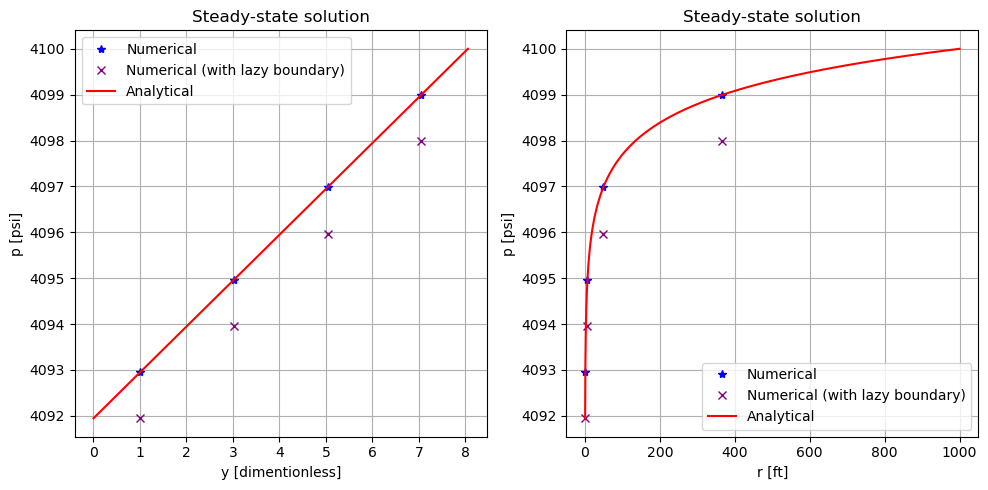

In [ ]:
import matplotlib.pyplot as plt

#Numerical solution
p, _ = numerical(alpha, y_e, delta_y, p_e, N, lazy = False)
p_lazy, y = numerical(alpha, y_e, delta_y, p_e, N, lazy = True)

#Analytical solution
ya = np.linspace(0, y_e, 1000)
pa = analytical(ya, alpha, y_e, p_init)

#Converting from y to real physical dimention r
r = r_w * np.exp(y)
ra = r_w * np.exp(ya)

#Plotting with coordinate transformation
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(y,p,'*', color = 'blue', label='Numerical')
ax[0].plot(y,p_lazy,'x', color = 'purple', label='Numerical (with lazy boundary)')
ax[0].plot(ya,pa, color = 'red', label='Analytical')
ax[0].legend()
ax[0].set_xlabel('y [dimentionless]')
ax[0].set_ylabel('p [psi]')
ax[0].set_title('Steady-state solution')
ax[0].grid()

#Plotting with real physical coordinates
ax[1].plot(r,p,'*', color = 'blue', label='Numerical')
ax[1].plot(r,p_lazy,'x', color = 'purple', label='Numerical (with lazy boundary)')
ax[1].plot(ra,pa, color = 'red', label='Analytical')
ax[1].legend()
ax[1].set_xlabel('r [ft]')
ax[1].set_ylabel('p [psi]')
ax[1].set_title('Steady-state solution')
ax[1].grid()
fig.tight_layout()
plt.show()

Furthermore, we analyze the error by comparing the numerical solution with the analytical solution.

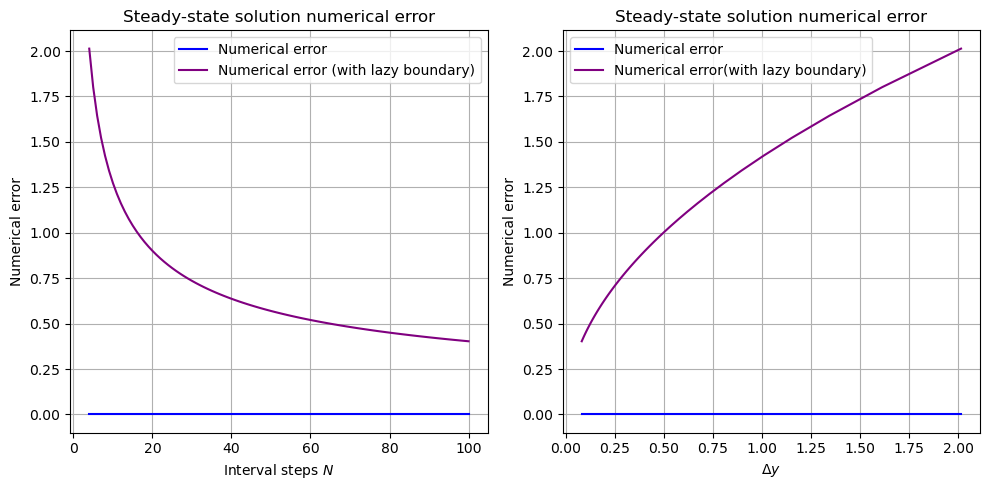

In [192]:
#Initializing
error_lazy = []
error = []
ns = np.linspace(4, 100, 100).astype(int)
dys = []

#Calculation different errors with differnt values for N
for i, N in enumerate(ns):
    delta_y = y_e/N
    p, _ = numerical(alpha, y_e, delta_y, p_e, N, lazy = False)
    p_lazy, y = numerical(alpha, y_e, delta_y, p_e, N, lazy = True)
    pa = analytical(y, alpha, y_e, p_init)
    error.append(np.linalg.norm(pa - p))
    error_lazy.append(np.linalg.norm(pa - p_lazy))
    dys.append(delta_y)

#Plotting error over interval steps N
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(ns,error,'-', color = 'blue', label='Numerical error')
ax[0].plot(ns,error_lazy,'-', color = 'purple', label='Numerical error (with lazy boundary)')
ax[0].legend()
ax[0].set_xlabel('Interval steps $N$')
ax[0].set_ylabel('Numerical error')
ax[0].set_title('Steady-state solution numerical error')
ax[0].grid()

#Plotting error over delta_y
ax[1].plot(dys, error,'-', color = 'blue', label='Numerical error')
ax[1].plot(dys, error_lazy,'-', color = 'purple', label='Numerical error(with lazy boundary)')
ax[1].legend()
ax[1].set_xlabel(r'$\Delta y$')
ax[1].set_ylabel('Numerical error')
ax[1].set_title('Steady-state solution numerical error')
ax[1].grid()

fig.tight_layout()
plt.show()

If we look at the left plot, we can see that by increasing the number of interval steps $N$ the numerical error decreases for the lazy boundary conditions. As for the "not so lazy" boundary condition we see almost no numerical error (if we zoom in, we can see some small round-off errors). We believe this happens because the analytical solution to the steady state is linear, so by using exact boundary conditions we are rewarded with almost no error. On the other hand, using the lazy boundary, we misplace the boundary slightly and therefore it is not perfectly aligned which we can see by the right plot gives us a (almost) first order error as we expected from our calculations in part $4$.

# Exercise 2: Time-dependent solution

**Intro here**

## Part 1

$$\frac{p^{n+1}_{i}- p^{n}_{i}}{\Delta t} = \eta \cdot \frac{e^{-2y_i}}{r_w^2} \cdot \frac{p^{n+1}_{i+1} + p^{n+1}_{i-1} - 2p^{n+1}_{i}}{\Delta y^2}$$

Multiply by $\Delta t$ :

$$p^{n+1}_{i}- p^{n}_{i} = \eta \cdot \frac{e^{-2y_i} \Delta t}{r_w^2} \cdot \frac{p^{n+1}_{i+1} + p^{n+1}_{i-1} - 2p^{n+1}_{i}}{\Delta y^2}$$

Rewrite by combining denominator of last two fractions 

$$p^{n+1}_{i}- p^{n}_{i} = \eta \cdot \frac{e^{-2y_i} \Delta t}{r_w^2 \cdot \Delta y^2} \cdot \left(p^{n+1}_{i+1} + p^{n+1}_{i-1} - 2p^{n+1}_{i}\right)$$

To simplify calculations we set:

$$\xi_i = \eta \cdot \frac{e^{-2y_i} \Delta t}{r_w^2 \cdot \Delta y^2}$$

Now we put $p^{n+1}$ on the left hand side and $p^n$ on the right hand side:

$$p^{n+1}_{i} - \xi_i \cdot \left(p^{n+1}_{i+1} + p^{n+1}_{i-1} - 2p^{n+1}_{i}\right) =   p^{n}_{i} \quad \Rightarrow \quad p^{n+1}_{i} - \xi_i p^{n+1}_{i+1} - \xi_i p^{n+1}_{i-1} + \xi_i 2p^{n+1}_{i} =   p^{n}_{i} $$

Since we have $N = 4$ we can set $i = 0, 1, 2, 3$. You will now see that we end up with four equations, but six unknowns for the left hand side $(p^{n+1}_{-1}, p^{n+1}_0, p^{n+1}_1, p^{n+1}_2, p^{n+1}_3, p^{n+1}_4)$:

\begin{align*}
i &= 0: \quad \quad &&p^{n+1}_{0} - \xi_0 p^{n+1}_{1} - \xi_0 p^{n+1}_{-1} + \xi_0 2p^{n+1}_{0} = p^{n}_{0}\\
i &= 1: \quad \quad &&p^{n+1}_{1} - \xi_1 p^{n+1}_{2} - \xi_1 p^{n+1}_{0} + \xi_1 2p^{n+1}_{1} = p^{n}_{1}\\
i &= 2: \quad \quad &&p^{n+1}_{2} - \xi_2 p^{n+1}_{3} - \xi_2 p^{n+1}_{1} + \xi_2 2p^{n+1}_{2} = p^{n}_{2}\\
i &= 3: \quad \quad &&p^{n+1}_{3} - \xi_3 p^{n+1}_{4} - \xi_3 p^{n+1}_{2} + \xi_3 2p^{n+1}_{3} = p^{n}_{3}\\
\end{align*}

In order to find $p_{-1}^{n+1}$ we will use the forward difference. Note that we also tried to calculate it using the central difference, but the solution did not match equation $(24)$. 

$$\frac{p_{i+1}^{n+1} - p_{i}^{n+1}}{\Delta y} = \frac{Q u}{2 \pi h k} \quad \xRightarrow{i = -1} \quad \frac{p_{0}^{n+1} - p_{-1}^{n+1}}{\Delta y} = \frac{Q u}{2 \pi h k}$$

Multiply with $\Delta y$ and solve for $p_{-1}^{n+1}$:

$$- p_{-1}^{n+1} = \frac{Q u \Delta y}{2 \pi h k} - p_{0}^{n+1} \quad \Rightarrow \quad p_{-1}^{n+1} = -\frac{Q u \Delta y}{2 \pi h k} + p_{0}^{n+1} $$

Before we insert $p_{-1}^{n+1}$ into our solution we introduce a new varible $\beta$ to simplify calculations: 

$$\beta = \frac{Q u \Delta y}{2 \pi h k}\quad \Rightarrow \quad p_{-1}^{n+1} = -\beta + p_{0}^{n+1}$$

Adding our solution for $p_{-1}^{n+1}$:

\begin{align*}
i &= 0: \quad \quad p^{n+1}_{0} - \xi_0 p^{n+1}_{1} - \xi_0 \left( -\beta + p_{0}^{n+1}\right) + \xi_0 2p^{n+1}_{0} &&= p^{n}_{0}\\
i &= 1: \quad \quad p^{n+1}_{1} - \xi_1 p^{n+1}_{2} - \xi_1 p^{n+1}_{0} + \xi_1 2p^{n+1}_{1} &&= p^{n}_{1}\\
i &= 2: \quad \quad p^{n+1}_{2} - \xi_2 p^{n+1}_{3} - \xi_2 p^{n+1}_{1} + \xi_2 2p^{n+1}_{2} &&= p^{n}_{2}\\
i &= 3: \quad \quad p^{n+1}_{3} - \xi_3 p^{n+1}_{4} - \xi_3 p^{n+1}_{2} + \xi_3 2p^{n+1}_{3} &&= p^{n}_{3}\\
\end{align*}

With some simple algebra we get: 

\begin{align*}
i &= 0: \quad \quad \left(1 + \xi_0 \right)p^{n+1}_{0} - \xi_0 p^{n+1}_{1}  &&= p^{n}_{0} - \xi_0 \beta\\
i &= 1: \quad \quad \left(1 + 2\xi_1 \right)p^{n+1}_{1} - \xi_1 p^{n+1}_{2} - \xi_1 p^{n+1}_{0} &&= p^{n}_{1}\\
i &= 2: \quad \quad \left(1 + 2\xi_2\right)p^{n+1}_{2} - \xi_2 p^{n+1}_{3} - \xi_2 p^{n+1}_{1} &&= p^{n}_{2}\\
i &= 3: \quad \quad \left(1 + 2\xi_3 \right)p^{n+1}_{3} - \xi_3 p^{n+1}_{4} - \xi_3 p^{n+1}_{2} &&= p^{n}_{3}\\
\end{align*}

Now we only have to replace $p_4^{n+1}$, and to do this we use the boundary condition $p_N^{n+1} = 2p_i - p_{N-1}^{n+1}$. This will for our case ($N = 4$) be $p_4^{n+1} = 2p_i - p_3^{n+1}$ 

\begin{align*}
i &= 0: \quad \quad \left(1 + \xi_0 \right)p^{n+1}_{0} - \xi_0 p^{n+1}_{1}  &&= p^{n}_{0} - \xi_0 \beta\\
i &= 1: \quad \quad \left(1 + 2\xi_1 \right)p^{n+1}_{1} - \xi_1 p^{n+1}_{2} - \xi_1 p^{n+1}_{0} &&= p^{n}_{1}\\
i &= 2: \quad \quad \left(1 + 2\xi_2\right)p^{n+1}_{2} - \xi_2 p^{n+1}_{3} - \xi_2 p^{n+1}_{1} &&= p^{n}_{2}\\
i &= 3: \quad \quad \left(1 + 2\xi_3 \right)p^{n+1}_{3} - \xi_3 \left( 2p_i - p_3^{n+1}\right) - \xi_3 p^{n+1}_{2} &&= p^{n}_{3}\\
\end{align*}

With some algebra we get: 

\begin{align*}
i &= 0: \quad \quad \left(1 + \xi_0 \right)p^{n+1}_{0} - \xi_0 p^{n+1}_{1}  &&= p^{n}_{0} - \xi_0 \beta\\
i &= 1: \quad \quad \left(1 + 2\xi_1 \right)p^{n+1}_{1} - \xi_1 p^{n+1}_{2} - \xi_1 p^{n+1}_{0} &&= p^{n}_{1}\\
i &= 2: \quad \quad \left(1 + 2\xi_2\right)p^{n+1}_{2} - \xi_2 p^{n+1}_{3} - \xi_2 p^{n+1}_{1} &&= p^{n}_{2}\\
i &= 3: \quad \quad \left(1 + 3\xi_3 \right)p^{n+1}_{3} - \xi_3 p^{n+1}_{2} &&= p^{n}_{3} + 2 \xi_3 p_i \\
\end{align*}

If we now write the equations in matrix form ($\textbf{A} \textbf{p}^{n+1} = \textbf{p}^n + \textbf{d}$) we get a matrix identical to equation $(24)$:

$$
\begin{pmatrix}
1 + \xi_0 & -\xi & 0 & 0 \\
-\xi_1 & 1 + 2\xi_1 & -\xi_1 & 0 \\
0 & -\xi_2 & 1 + 2 \xi_2 & -\xi_2 \\
0 & 0 & -\xi_3 & 1 + 3\xi_3
\end{pmatrix}
\begin{pmatrix}
p_0^{n+1} \\
p_1^{n+1} \\
p_2^{n+1} \\
p_3^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
p_0^{n} \\
p_1^{n} \\
p_2^{n} \\
p_3^{n}
\end{pmatrix}
+ 
\begin{pmatrix}
-\xi_0 \beta\\
0 \\
0 \\
2 \xi_3 p_i
\end{pmatrix}
$$

## Part 2

In [ ]:
import pandas as pd
import scipy as scipy
import scipy.sparse as sp
from scipy.optimize import curve_fit
import math
from ThomasAlgorithm import ThomasAlgorithm as thomas

class PressureSolver:
    '''
    A finite difference solver to solve pressure distribution in
    a reservoir, logarithmic grid has been used, y = ln(r/rw)
    The solver uses SI units internally, while "practical field units"
    are required as input.

    Input arguments:
    ------------------------------------------------------------------
    name                          symbol       unit
    ------------------------------------------------------------------
    Number of grid points         N            dimensionless
    Constant time step            dt           days
    Type of solver                solver
    Length of simulation          days         days
    Well radius                   rw           ft
    Outer reservoir boundary      re           ft
    Height of reservoir           h            ft
    Absolute permeability         k            mD
    Porosity                      phi          dimensionless
    Fluid viscosity               mu           mPas (cP)
    Total (rock+fluid)
    compressibility               ct           1/psi
    Constant flow rate at well    Q            bbl/day
    Initial reservoir pressure    pi           psi
    ------------------------------------------------------------------
    '''

    def __init__(self,
                    N = 4,
                    dt = 0.01,
                    solver = 'Dense',
                    days = 0.5,
                    rw=0.318,
                    re=1000.0,
                    h=11.0,
                    phi=0.25,
                    mu=1.0,
                    ct=7.8e-6,
                    Q=1000.0,
                    k=500,
                    pi=4100.0):

        #Unit conversion factors (input units --> SI)
        self.ft_to_m_ = 0.3048
        self.psi_to_pa_ = 6894.75729
        self.day_to_sec_ = 24.*60.*60.
        self.bbl_to_m3_ = 0.1589873

        #Grid
        self.N_ = N
        self.rw_ = rw*self.ft_to_m_
        self.re_ = re*self.ft_to_m_
        self.h_ = h*self.ft_to_m_

        #Rock and fluid properties
        self.k_ = k*1e-15 / 1.01325 #From Darcy to m^2
        self.phi_ = phi
        self.mu_ = mu*1e-3 #From cP to Pas
        self.ct_ = ct / self.psi_to_pa_

        #Initial and boundary conditions
        self.Q_ = Q*self.bbl_to_m3_ / self.day_to_sec_
        self.pi_ = pi*self.psi_to_pa_

        #Time control for simulation
        self.dt_ = dt*self.day_to_sec_

        #NEED names
        self.y_e_ = np.log(self.re_ / self.rw_)
        self.dy_ = self.y_e_/ self.N_
        self.y_ = np.arange(self.dy_/2.0, self.y_e_, self.dy_)

        self.eta_ = self.k_ / (self.mu_ * self.phi_ * self.ct_)
        self.xi_  = (self.eta_*np.exp(-2*self.y_) * self.dt_) / (self.rw_**2 * self.dy_**2)
        self.beta_ = (self.Q_ * self.mu_ * self.dy_) / (2 * np.pi * self.k_ * self.h_)

        self.days_ = days
        self.solver_ = solver

        # TO DO: Add more stuff below here....
        # (grid coordinates, dy, eta, etc.)

    def tri_diag(self,a, b, c, k1=-1, k2=0, k3=1):
        '''
        a,b,c diagonal terms
        | b0 c0 0 0|
        | a0 b1 c1 0 |
        | 0 a1 b2 c2|
        | 0 0 a2 b3|
        returns a tridiagonal matrix
        '''
        return np.diag(a, k1) + np.diag(b, k2) + np.diag(c, k3)

    def set_up_matrix_for_time_dependent(self, print_A = False):
        '''
        Sets up the matrix A doe time dependant
        '''
        #Defining the diagonal terms
        a = -self.xi_[1:] * np.ones(self.N_- 1)
        b = (1 + 2*self.xi_)*np.ones(self.N_)
        c = -self.xi_[:-1] * np.ones(self.N_ - 1)

        #Adjustments
        b[0] = 1 + self.xi_[0]
        b[-1] = 1 + 3*self.xi_[-1]

        #Defining the matrix
        if self.solver_ == 'Dense':
            self.A = self.tri_diag(a, b, c)
        elif self.solver_ == 'Sparse':
            data=np.zeros((3,self.N_))
            data[0,:-1]= a
            data[1,:]  = b
            data[2,1:] = c
            diag = [-1, 0, 1]
            self.A = sp.spdiags(data, diag, m = self.N_, n = self.N_, format='csc')
        elif self.solver_ == 'Thomas':
            self.l = a
            self.d = b
            self.u = c

    def set_up_rhs_for_time_dependent(self, p_old):
        #Defining the d matrix
        self.rhs = np.zeros(self.N_)
        self.rhs[0] = -self.beta_ * self.xi_[0]
        self.rhs[-1] = 2 * self.pi_ * self.xi_[self.N_ - 1]
        self.rhs = self.rhs + p_old

    def solve_time_dependent(self,plot = True):
        #Set up A matrix
        self.set_up_matrix_for_time_dependent()

        #Initialize values
        t = 0.0
        t_final = self.days_ * self.day_to_sec_
        p_old = np.repeat(self.pi_, self.N_) #(N,1) matrix with p_i
        self.pressure_over_time = []
        self.times = []

        #Add start time and initial pressure
        self.times.append(t)
        self.pressure_over_time.append(p_old)

        while t <= t_final:
            #Setting up rhs
            self.set_up_rhs_for_time_dependent(p_old)

            #Solve
            if self.solver_ == 'Dense':
                p_new = np.linalg.solve(self.A, self.rhs)
            elif self.solver_ == 'Sparse':
                p_new = sp.linalg.spsolve(self.A, self.rhs)
            elif self.solver_ == 'Thomas':
                p_new = thomas.solve(self.l, self.d, self.u, self.rhs)

            #Update values and add new values to lists
            t += self.dt_
            self.pressure_over_time.append(p_new)
            self.times.append(t)
            p_old = p_new

        #Uses vstack to simplify plotting
        self.pressure_over_time = np.vstack(self.pressure_over_time)

        #Plots
        if plot == True:
            plt.plot(self.times, self.pressure_over_time)
            plt.xlabel('Time [s]')
            plt.ylabel('Pressure [Pa]')
            plt.title('Time-dependent solution')
            plt.show()

    def line_source_solution(self, r, t):
        W = scipy.special.expi(- (r**2)/ (4* self.eta_ * t))
        return self.pi_ + (self.Q_ * self.mu_) / (4* np.pi * self.k_ * self.h_) * W

    def compare_analytical_and_numerical(self):
        self.solve_time_dependent(plot = False)

        #Converting from y to real physical dimention r
        ya = np.linspace(0, self.y_e_, 1000)

        r = self.rw_ * np.exp(self.y_)
        ra = self.rw_ * np.exp(ya)

        #We want to compare at the first quarter
        midway_point = math.ceil(len(self.times) / 4) #Round up to nearest int

        t = self.times[midway_point]
        p_numerical = self.pressure_over_time[midway_point, : ].T

        #Gets analytical solution
        p = self.line_source_solution(ra,t)

        plt.plot(r, p_numerical, '*', color = 'blue', label = 'Numerical')
        plt.plot(ra, p, '-', color = 'red', label = 'Analytical')
        plt.xlabel('r [m]')
        plt.ylabel('Pressure [Pa]')
        plt.title('Compare analytical and numerical')
        plt.legend()
        plt.grid()
        plt.show()

    def calc_well_pressure(self, p0):
        return p0[1:] - (self.beta_)/2


$$\textcolor{red}{\text{Need some explainations}}$$

In [6]:
ps = PressureSolver(N = 4, dt = 0.01)
ps.set_up_matrix_for_time_dependent()
print(ps.A)

[[ 5.28702460e+03 -5.28602460e+03  0.00000000e+00  0.00000000e+00]
 [-9.42633218e+01  1.89526644e+02 -9.42633218e+01  0.00000000e+00]
 [ 0.00000000e+00 -1.68095582e+00  4.36191165e+00 -1.68095582e+00]
 [ 0.00000000e+00  0.00000000e+00 -2.99757363e-02  1.08992721e+00]]


## Part 3

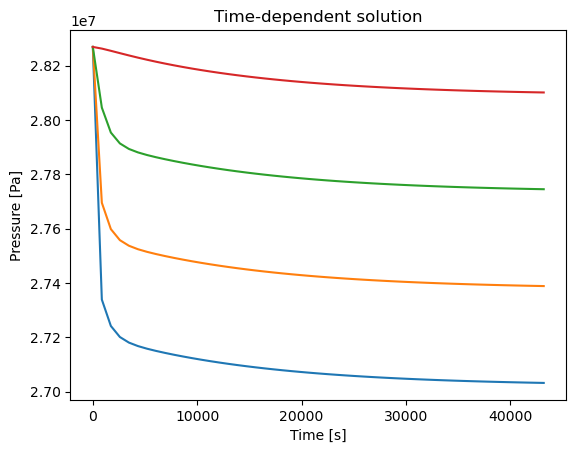

In [7]:
ps.solve_time_dependent()

# Exercise 3

**Intro here**

## Part 1

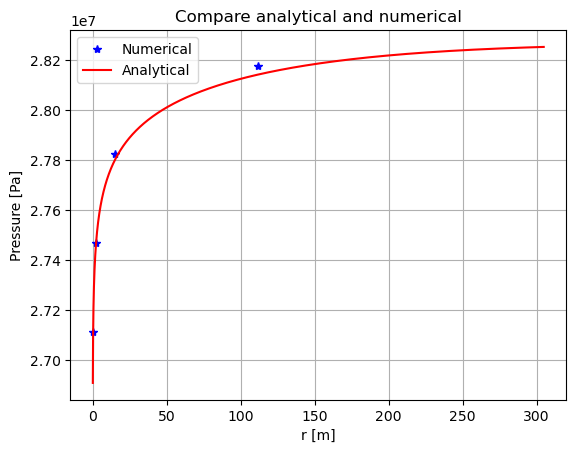

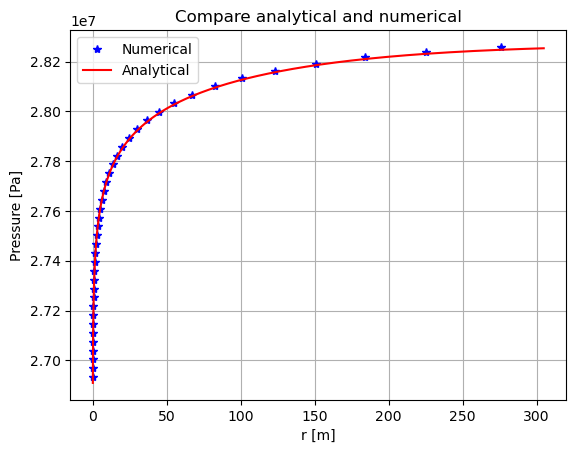

In [174]:
ps1 = PressureSolver(N = 4, dt = 0.01)
ps2 = PressureSolver(N = 40, dt = 0.01)

ps1.compare_analytical_and_numerical()
ps2.compare_analytical_and_numerical()

## Part 2

In [9]:
ps_dense_4 = PressureSolver(N = 4, dt = 0.01, solver = 'Dense')
ps_sparse_4 = PressureSolver(N = 4, dt = 0.01, solver = 'Sparse')
ps_thomas_4 = PressureSolver(N = 4, dt = 0.01, solver = 'Thomas')

ps_dense_400 = PressureSolver(N = 400, dt = 0.01, solver = 'Dense')
ps_sparse_400 = PressureSolver(N = 400, dt = 0.01, solver = 'Sparse')
ps_thomas_400 = PressureSolver(N = 400, dt = 0.01, solver = 'Thomas')

%timeit ps_dense_4.solve_time_dependent(plot = False)
%timeit ps_sparse_4.solve_time_dependent(plot = False)
%timeit ps_thomas_4.solve_time_dependent(plot = False)

%timeit ps_dense_400.solve_time_dependent(plot = False)
%timeit ps_sparse_400.solve_time_dependent(plot = False)
%timeit ps_thomas_400.solve_time_dependent(plot = False)

483 μs ± 3.27 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.42 ms ± 26.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
295 μs ± 55.8 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
71.2 ms ± 3.64 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
7.37 ms ± 93.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
579 μs ± 3.28 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Exercice 4

## Part 1

## Part 2

In [110]:
def read_well_data(plot = False):
    '''
    Doc string
    '''
    try:
        data = pd.read_csv('well_bhp.dat',sep = '\t')

        if plot:
            plt.scatter(data['time'], data['well_pressure'], color = 'blue')
            plt.xlabel('time [min]')
            plt.ylabel('Pressure [psi]')
            plt.title('Well pressure data over time')
            plt.show()
        return data
    except Exception as e:
        print(f'Failed to retrive data.\nError: {e}')
        return pd.DataFrame()

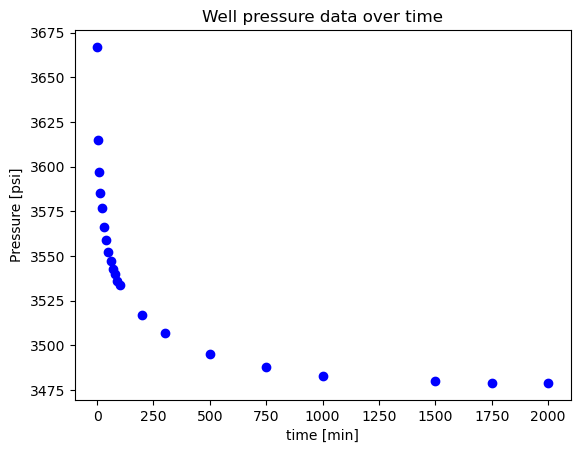

In [111]:
data = read_well_data(plot = True)

## Part 3

In [179]:
def numerical_well_pressure_over_time(t, k, pi, re):
    #Setting days to match the well data
    days = 2000 / (60*24)
    dt = 1 / (60*24)
    N = 4
    solver = 'Dense'

    #Creating a PressureSolver instance
    ps = PressureSolver(N = N, dt = dt , solver = solver,
                        days = days, k = k, pi = pi, re = re)

    #Setting up and solving matrix
    ps.solve_time_dependent(plot = False)

    #Pressure p0 will be in the first column
    p0 = ps.pressure_over_time[:, 0] #[pa]

    #Using p0 to calculate pw and converting it to psi
    pw_model = ps.calc_well_pressure(p0) / ps.psi_to_pa_

    #Gets times from model
    t_model = np.array(ps.times)/60.0 #[min]
    t_model = t_model[1:]

    #Interpolate model to data time points
    return np.interp(t, t_model, pw_model)

def fitting_well_data(plot = True):
    '''
    Doc string
    '''
    #Reading and sorting well data
    data = read_well_data(plot = False)
    t_data = data['time']
    pw_data = data['well_pressure']

    # Initial guesses: [k, pi, re]
    initial_guess = [500.0, 4100.0, 1000.0]

    #Automatic curve fitting
    popt, _ = curve_fit(numerical_well_pressure_over_time, t_data, pw_data, p0=initial_guess)

    #Sorting parameters
    k = popt[0]
    pi = popt[1]
    re = popt[2]

    if plot:
        #Fitted curve
        t_fit = np.linspace(min(t_data), max(t_data), 1000)
        pw_fit = numerical_well_pressure_over_time(t_fit, *popt)

        #Line source solution
        ps = PressureSolver(k = k, pi = pi - 100, re = re)
        t_ls = t_fit
        p_ls = ps.line_source_solution(r = ps.rw_, t = t_ls) / ps.psi_to_pa_

        #Plotting
        plt.scatter(t_data, pw_data, label='Well data')
        plt.plot(t_fit, pw_fit, color='red', label='Fitted curve')
        plt.plot(t_ls, p_ls, color='Purple', label='Line source solution')
        plt.xlabel('Time [min]')
        plt.ylabel('Well Pressure [psi]')
        plt.title(f'Fitted curve over well data.\n Fitted parameters: k = {k:.2f}, pi = {pi:.2f}, re = {re:.2f}')
        plt.legend()
        plt.xscale('log')
        plt.show()

    return k, pi, re

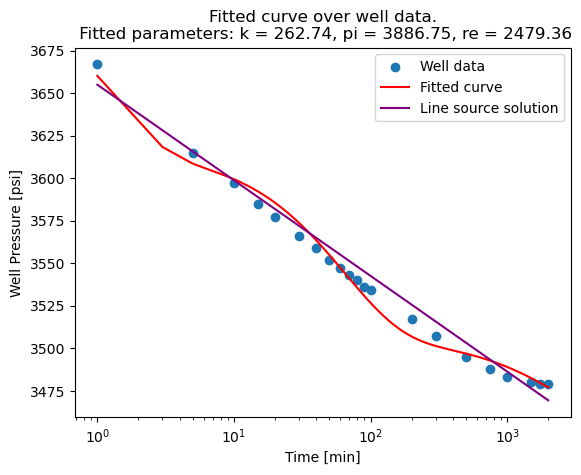

In [180]:
k, pi, re = fitting_well_data(plot = True)

## Part 4

# Bibliography

\[1\] M. Newman, *Computational Physics*. San Francisco, CA, USA: CreateSpace Independent Publishing Platform, 2013.